  ## 1. Inicjalizacja i Konfiguracja Parametrów



  Miejsce na importy bibliotek oraz definicje wszystkich ścieżek, dat i parametrów modelu.

In [1]:
# %%
import os
import time
import pickle
import warnings
import numpy as np
import pandas as pd
import xgboost as xgb
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime, timedelta
from bayes_opt import BayesianOptimization
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import TimeSeriesSplit
from sklearn.linear_model import Ridge  # <--- DODANO: Model do wyznaczania trendu bazowego

warnings.filterwarnings('ignore')
np.random.seed(123)
os.environ['TZ'] = 'UTC'

# --- Konfiguracja Ścieżek ---
path_events = r"W:\Dzial Business process\Dzial Analiz\OSOBISTE\RAFAŁ\Wewnętrzne\Events_ratings.xlsx"
path_pogoda = r"C:\DanePYTHON\ATV\raport pogodowy - wykresy ATV.xlsx"
nazwa_pliku_prognoza = "ATV_prognoza_2026_09.xlsx"

# --- Parametry Czasowe ---
zmienna_obj = "ATV"
Start_date = pd.to_datetime("2021-08-05").date()
last_update_date = pd.to_datetime("2026-08-07").date()
End_date = last_update_date - timedelta(days=1)
Start_prognozowanego_miesiaca = pd.to_datetime("2026-09-01").date()
End_pred = pd.to_datetime("2026-09-30").date()

# --- Definicja Zmiennych i Okien ---
lags_def = [8760]
windows_def = [672, 8760]

# Parametry do modelu odchyleń (XGBoost)
zmienne = [
    "Label", "Rank", "Holiday", "Weekend", 
    "Daypart", 
    "Hour", "Weekday", "Month", "Year",
    "Hour_int", "Weekday_int", "Month_int", "Year_int", 
    "Day_of_year",
    "Hour_sin", "Hour_cos", "Weekday_sin", "Weekday_cos", "Year_sin", "Year_cos",
    "Sunset", 
    "Hours_after_sunset", 
    "After_sunset", "Trend", "Trend2",
    "Temperatura maks.", "%Czas opadów",
    "Lag_mean_4_weeks", "Is_event_in_Lag_mean"
]

for lag in lags_def:
    zmienne.extend([f"Lag_{lag}", f"Is_event_in_Lag_{lag}"])
for w in windows_def:
    zmienne.extend([f"Roll_mean_{w}", f"Is_event_in_Roll_{w}"])

zmienne_trendu = [
    "Trend",  
    "Year_sin", "Year_cos",     # Łapie sezonowość roczną (lato vs zima)
    "Weekday_sin", "Weekday_cos", # Łapie układ tygodnia
    "Hour_sin", "Hour_cos"      # Łapie układ dnia (Prime Time itp.)
]

  ## 2. Funkcje Pomocnicze



  Transformacja dat i podziały dla walidacji krzyżowej.

In [2]:
def parse_nielsen_datetime(df):
    df_out = df.copy()
    df_out['Date'] = pd.to_datetime(df_out['Date']).dt.normalize()
    
    times_raw = df_out['Daypart'].astype(str).str.extract(r'(\d{4})', expand=False)
    valid_mask = times_raw.notna()
    df_out = df_out[valid_mask].copy()
    times_raw = times_raw[valid_mask]
    
    time_strings = times_raw.str[:2] + ":" + times_raw.str[2:] + ":00"
    df_out['DT'] = df_out['Date'] + pd.to_timedelta(time_strings)
    df_out['Date'] = df_out['DT'].dt.date
    df_out['Time'] = df_out['DT'].dt.strftime('%H:%M:%S')
    df_out['DT'] = df_out['DT'].dt.tz_localize('UTC')
    
    return df_out.drop(columns=['Daypart'])

def create_time_slices(n_samples, initial_window, horizon, skip):
    folds = []
    train_end = initial_window
    while train_end + horizon <= n_samples:
        train_idx = np.arange(0, train_end)
        test_idx = np.arange(train_end, train_end + horizon)
        folds.append((train_idx, test_idx))
        train_end += (skip + 1)
    return folds




  ## 3. Import i Przetwarzanie Danych Historycznych



  Łączenie ramek danych, inżynieria cech (feature engineering).

In [3]:
print("Wczytywanie i processing danych...")

# --- Dane Główne (ATV) ---
dane = pd.read_csv("Time ATV_hourly_TSV.csv", skiprows=10, decimal=",").rename(columns={"TRP (avgW)": "ATV"})
dane = parse_nielsen_datetime(dane)
dane = dane.set_index('DT').resample('1H').asfreq().reset_index()
dane = dane[["DT", "Date", "Time", "ATV"]].sort_values("DT").reset_index(drop=True)
dane["logATV"] = np.log1p(dane["ATV"])

# --- Zewnętrzne Źródła ---
Events_dane = pd.read_excel(path_events, sheet_name="Events_full")
Events_dane["DT"] = pd.to_datetime(Events_dane["DT"], utc=True)
Events_dane["End_DT"] = Events_dane["DT"] + pd.to_timedelta(Events_dane["Duration"].astype(str))
Events_dane = Events_dane.sort_values("DT")

Holiday_dane = pd.read_excel(path_events, sheet_name="Holiday_full")
Holiday_dane["Date"] = pd.to_datetime(Holiday_dane["Data"]).dt.date
Holiday_dane = Holiday_dane[["Date", "Holiday"]].drop_duplicates()

DDT_dane = pd.read_excel(path_events, sheet_name="DDT")
DDT_dane["Date"] = pd.to_datetime(DDT_dane["Date"]).dt.date
DDT_dane = DDT_dane.drop_duplicates()

Pogoda_dane = pd.read_excel(path_pogoda)
Pogoda_dane["Date"] = pd.to_datetime(Pogoda_dane["Data"]).dt.date
Pogoda_dane = Pogoda_dane[["Date", "Temperatura maks.", "%Czas opadów"]].drop_duplicates(subset=["Date"], keep="last")
Pogoda_dane[["Temperatura maks.", "%Czas opadów"]] = Pogoda_dane[["Temperatura maks.", "%Czas opadów"]].apply(pd.to_numeric, errors="coerce")

Pogoda_dane["Month_int"] = pd.to_datetime(Pogoda_dane["Date"]).dt.month
srednie_miesieczne_pogoda = Pogoda_dane.groupby("Month_int")[["Temperatura maks.", "%Czas opadów"]].mean().reset_index()
srednie_miesieczne_pogoda.rename(columns={"Temperatura maks.": "Temp_srednia_msc", "%Czas opadów": "Opady_srednia_msc"}, inplace=True)

# --- Łączenie Danych ---
dane = pd.merge_asof(dane, Events_dane[["DT", "End_DT", "Label", "Rank"]], on="DT", direction="backward")
dane.loc[dane["DT"] >= dane["End_DT"], ["Label", "Rank"]] = None
dane.drop(columns="End_DT", inplace=True)
dane["Label"] = dane["Label"].fillna("Brak")
dane["Rank"] = dane["Rank"].fillna(0)
dane["event_flag"] = (dane["Label"] != "Brak").astype(int)

dane = dane.merge(Holiday_dane, on="Date", how="left")
dane["Holiday"] = dane["Holiday"].fillna("Brak")
dane = dane.merge(DDT_dane[["Date", "Sunset"]], on="Date", how="left")
dane = dane.merge(Pogoda_dane, on="Date", how="left")
dane = dane.merge(srednie_miesieczne_pogoda, on="Month_int", how="left")
dane["Temperatura maks."] -= dane["Temp_srednia_msc"]
dane["%Czas opadów"] -= dane["Opady_srednia_msc"]
dane.drop(columns=["Temp_srednia_msc", "Opady_srednia_msc"], inplace=True)

# --- Zmienne Czasowe i Kalendarzowe ---
dane["Hour_int"] = dane["DT"].dt.hour
dane["Hour"] = dane["Hour_int"].astype(str).str.zfill(2)
dane["Weekday_int"] = dane["DT"].dt.weekday
dane["Weekday"] = dane["DT"].dt.day_name()
dane["Month_int"] = dane["DT"].dt.month
dane["Month"] = dane["DT"].dt.month_name()
dane["Quarter_int"] = dane["DT"].dt.quarter
dane["Year_int"] = dane["DT"].dt.year
dane["Year"] = dane["DT"].dt.year.astype(str)
dane["Day_of_year"] = dane["DT"].dt.dayofyear

time_minutes = dane["Hour_int"] * 60 + dane["DT"].dt.minute
dane["Daypart"] = np.select(
    [
        (time_minutes >= 360) & (time_minutes < 510),
        (time_minutes >= 510) & (time_minutes < 900),
        (time_minutes >= 900) & (time_minutes < 1020),
        (time_minutes >= 1020) & (time_minutes < 1380)
    ],
    ["Morning Time", "Day Time", "Early Fringe", "Prime Time"],
    default="Late Night"
)

dane["Hour_sin"] = np.sin(2 * np.pi * dane["Hour_int"] / 24)
dane["Hour_cos"] = np.cos(2 * np.pi * dane["Hour_int"] / 24)
dane["Weekday_sin"] = np.sin(2 * np.pi * dane["Weekday_int"] / 7)
dane["Weekday_cos"] = np.cos(2 * np.pi * dane["Weekday_int"] / 7)
dane["Year_sin"] = np.sin(2 * np.pi * dane["Day_of_year"] / 365.25)
dane["Year_cos"] = np.cos(2 * np.pi * dane["Day_of_year"] / 365.25)

dane["PrimeTime"] = dane["Hour_int"].between(17, 22).astype(int)
dane["PrimeTimeNarrow"] = dane["Hour_int"].between(19, 21).astype(int)
dane["Weekend"] = (dane["Weekday_int"] >= 5).astype(int)

dane["Sunset"] = pd.to_timedelta(dane["Sunset"].astype(str), errors="coerce").dt.total_seconds() / 3600
dane["Hours_after_sunset"] = dane["Hour_int"] - dane["Sunset"]
dane["After_sunset"] = (dane["Hours_after_sunset"] >= 0).astype(int)

dane["Trend"] = np.arange(len(dane))
dane["Trend2"] = dane["Trend"] ** 2

# --- Lagi i Rolling Windows ---
for lag in lags_def:
    dane[f"Lag_{lag}"] = dane["ATV"].shift(lag)
    dane[f"Is_event_in_Lag_{lag}"] = dane["event_flag"].shift(lag).fillna(0).astype(int)

for w in windows_def:
    dane[f"Roll_mean_{w}"] = dane["ATV"].shift(1).rolling(w).mean()
    dane[f"Roll_std_{w}"] = dane["ATV"].shift(1).rolling(w).std()
    dane[f"Is_event_in_Roll_{w}"] = dane["event_flag"].shift(1).rolling(w).max().fillna(0).astype(int)

# DODANO: Obliczenia wektorowe dla Lag_mean_4_weeks i Is_event_in_Lag_mean
lags_4w = [168, 336, 504, 672]
dane["holiday_flag"] = (dane["Holiday"] != "Brak").astype(int)
dane["event_or_holiday"] = dane[["event_flag", "holiday_flag"]].max(axis=1)

for lag in lags_4w:
    dane[f"Temp_Lag_{lag}"] = dane["ATV"].shift(lag)
    dane[f"Temp_Event_{lag}"] = dane["event_or_holiday"].shift(lag)

dane["Lag_mean_4_weeks"] = dane[[f"Temp_Lag_{lag}" for lag in lags_4w]].mean(axis=1)
dane["Is_event_in_Lag_mean"] = dane[[f"Temp_Event_{lag}" for lag in lags_4w]].max(axis=1).fillna(0).astype(int)

dane.drop(columns=[f"Temp_Lag_{lag}" for lag in lags_4w] + [f"Temp_Event_{lag}" for lag in lags_4w] + ["holiday_flag", "event_or_holiday"], inplace=True)

#dane["Diff_24"] = dane["Lag_1"] - dane["Lag_24"]
#dane["Diff_168"] = dane["Lag_1"] - dane["Lag_168"]
#dane["Ratio_168"] = dane["Lag_1"] / (dane["Lag_168"] + 1e-6)

dane = dane.sort_values("DT").drop_duplicates(subset=["DT"]).loc[dane["DT"].dt.date <= pd.to_datetime(End_date).date()].reset_index(drop=True)

Wczytywanie i processing danych...


  ## 4. Optymalizacja i Trening Modelu (Trend + XGBoost)



  Strojene hiperparametrów XGBoost na odchyleniach od głównego trendu (Ridge Regression).

In [4]:
print("Przygotowywanie danych do modelowania hybrydowego...")

max_dropna_lag = max(lags_def + windows_def) 
df_model = dane.iloc[max_dropna_lag:].dropna(subset=zmienne).reset_index(drop=True)

y = df_model[zmienna_obj].copy()
X = df_model[zmienne].copy()
X.drop(columns=[c for c in ["DT", zmienna_obj, "ATV"] if c in X.columns], errors="ignore", inplace=True)

kategorie_map = {}
cat_cols = ["Label", "Holiday", "Hour", "Daypart", "Weekday", "Month", "Year"]

for col in cat_cols:
    if col in X.columns:
        X[col] = X[col].astype(str).astype("category")
        kategorie_map[col] = X[col].cat.categories 
        X[col] = X[col].cat.codes.astype(int) 

X = X.astype(float) 
val_size = int(1.5 * 30 * 24)

X_train, y_train = X.iloc[:-val_size].copy(), y.iloc[:-val_size].copy()
X_val, y_val = X.iloc[-val_size:].copy(), y.iloc[-val_size:].copy()

best_n_estimators_list = []

def xgb_evaluate(max_depth, learning_rate, subsample, colsample_bytree, min_child_weight):
    tscv = TimeSeriesSplit(n_splits=3)
    rmse_scores, iterations = [], []
    
    for train_index, val_index in tscv.split(X_train):
        X_fold_train, X_fold_val = X_train.iloc[train_index], X_train.iloc[val_index]
        y_fold_train, y_fold_val = y_train.iloc[train_index], y_train.iloc[val_index]
        
        # 1. Obliczanie trendu na danych treningowych dla tego foldu
        trend_fold_model = Ridge(alpha=10.0)
        trend_fold_model.fit(X_fold_train[zmienne_trendu], y_fold_train)
        
        # Odjęcie trendu w celu wyznaczenia reszt (odchyleń)
        y_fold_train_resid = y_fold_train - trend_fold_model.predict(X_fold_train[zmienne_trendu])
        y_fold_val_resid = y_fold_val - trend_fold_model.predict(X_fold_val[zmienne_trendu])
        
        # 2. Trening XGBoost na resztach
        model = xgb.XGBRegressor(
            max_depth=int(max_depth), learning_rate=learning_rate, n_estimators=2000, 
            subsample=subsample, colsample_bytree=colsample_bytree, min_child_weight=min_child_weight,
            early_stopping_rounds=20, tree_method="hist", n_jobs=-1, random_state=123
        )
        model.fit(X_fold_train, y_fold_train_resid, eval_set=[(X_fold_val, y_fold_val_resid)], verbose=False)
        rmse_scores.append(model.best_score)
        iterations.append(model.best_iteration)
    
    best_n_estimators_list.append(np.mean(iterations)) 
    return -np.mean(rmse_scores)

xgb_bo = BayesianOptimization(
    f=xgb_evaluate,
    pbounds={"max_depth": (3, 10), "learning_rate": (0.01, 0.2), "subsample": (0.6, 1.0), "colsample_bytree": (0.6, 1.0), "min_child_weight": (1, 20)},
    random_state=123, verbose=0
)

print("\nRozpoczęcie optymalizacji bayesowskiej XGBoost na odchyleniach...")
xgb_bo.maximize(init_points=5, n_iter=20)

best_params = xgb_bo.max["params"]
best_params["max_depth"] = int(best_params["max_depth"]) 
best_iter_idx = max(range(len(xgb_bo.res)), key=lambda i: xgb_bo.res[i]['target'])
optimal_trees = int(best_n_estimators_list[best_iter_idx])

# Ocena walidacyjna obu modeli łącznie
eval_trend_model = Ridge(alpha=10.0)
eval_trend_model.fit(X_train[zmienne_trendu], y_train)
y_train_resid = y_train - eval_trend_model.predict(X_train[zmienne_trendu])

eval_xgb_model = xgb.XGBRegressor(**best_params, n_estimators=optimal_trees, tree_method="hist", random_state=123, n_jobs=-1)
eval_xgb_model.fit(X_train, y_train_resid)

preds_val_trend = eval_trend_model.predict(X_val[zmienne_trendu])
preds_val_resid = eval_xgb_model.predict(X_val)
preds_val_combined = preds_val_trend + preds_val_resid

rmse = np.sqrt(mean_squared_error(y_val, preds_val_combined))
print(f"Wyniki walidacyjne - R2: {r2_score(y_val, preds_val_combined):.4f} | RMSE: {rmse:.4f}")

# Trenowanie ostatecznych modeli (Trend + XGB) na całości dostępnych danych
final_trend_model = Ridge(alpha=10.0)
final_trend_model.fit(X[zmienne_trendu], y)
y_resid_full = y - final_trend_model.predict(X[zmienne_trendu])

final_xgb_model = xgb.XGBRegressor(**best_params, n_estimators=optimal_trees, tree_method="hist", random_state=123, n_jobs=-1)
final_xgb_model.fit(X, y_resid_full)




Przygotowywanie danych do modelowania hybrydowego...

Rozpoczęcie optymalizacji bayesowskiej XGBoost na odchyleniach...
Wyniki walidacyjne - R2: 0.9783 | RMSE: 1.0345


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,np.float64(0.6)
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import lo

  ## 5. Budowa Szablonu Prognozy



  Generowanie siatki czasowej i cech kalendarzowych dla przyszłych predykcji.

In [5]:
print("Przygotowywanie ramki danych dla okresu prognozy...")

start_prognozy = dane['DT'].max() + pd.Timedelta(hours=1)
end_prognozy = (pd.to_datetime(End_pred) + pd.Timedelta(hours=23)).tz_localize('UTC')

df_pred = pd.DataFrame({'DT': pd.date_range(start=start_prognozy, end=end_prognozy, freq='H')})
df_pred['Date'] = df_pred['DT'].dt.date
df_pred['Time'] = df_pred['DT'].dt.strftime('%H:%M:%S')
df_pred['ATV'], df_pred['logATV'] = np.nan, np.nan

Events_pred = Events_dane[(Events_dane['End_DT'] >= start_prognozy)].copy()
if not Events_pred.empty:
    df_pred = pd.merge_asof(df_pred.sort_values('DT'), Events_pred[['DT', 'End_DT', 'Label', 'Rank']].sort_values('DT'), on='DT', direction='backward')
    df_pred.loc[df_pred['DT'] >= df_pred['End_DT'], ['Label', 'Rank']] = None
    df_pred.drop(columns='End_DT', inplace=True, errors='ignore')
else:
    df_pred['Label'], df_pred['Rank'] = None, None

df_pred['Label'] = df_pred['Label'].fillna('Brak')
df_pred['Rank'] = df_pred['Rank'].fillna(0)
df_pred['event_flag'] = (df_pred['Label'] != 'Brak').astype(int)

df_pred = df_pred.merge(Holiday_dane, on='Date', how='left')
df_pred['Holiday'] = df_pred['Holiday'].fillna('Brak')

df_pred = df_pred.merge(DDT_dane[['Date', 'Sunset']], on='Date', how='left')
df_pred['Sunset'] = pd.to_timedelta(df_pred['Sunset'].astype(str), errors='coerce').dt.total_seconds() / 3600

df_pred['Month_int'] = df_pred['DT'].dt.month
df_pred = df_pred.merge(srednie_miesieczne_pogoda, on='Month_int', how='left')
df_pred = df_pred.merge(Pogoda_dane[['Date', 'Temperatura maks.', '%Czas opadów']], on='Date', how='left')

limit_pogody = last_update_date + timedelta(days=14)
mask_pogoda = df_pred['Date'] <= limit_pogody

df_pred['Temperatura maks.'] = np.where(mask_pogoda & df_pred['Temperatura maks.'].notna(), df_pred['Temperatura maks.'] - df_pred['Temp_srednia_msc'], 0.0)
df_pred['%Czas opadów'] = np.where(mask_pogoda & df_pred['%Czas opadów'].notna(), df_pred['%Czas opadów'] - df_pred['Opady_srednia_msc'], 0.0)
df_pred.drop(columns=['Temp_srednia_msc', 'Opady_srednia_msc'], inplace=True)

df_pred['Hour_int'] = df_pred['DT'].dt.hour
df_pred['Hour'] = df_pred['Hour_int'].astype(str).str.zfill(2)
df_pred['Weekday_int'] = df_pred['DT'].dt.weekday
df_pred['Weekday'] = df_pred['DT'].dt.day_name()
df_pred['Month'] = df_pred['DT'].dt.month_name()
df_pred['Quarter_int'] = df_pred['DT'].dt.quarter
df_pred['Year_int'] = df_pred['DT'].dt.year
df_pred['Year'] = df_pred['DT'].dt.year.astype(str)
df_pred['Day_of_year'] = df_pred['DT'].dt.dayofyear

time_minutes_pred = df_pred["DT"].dt.hour * 60 + df_pred["DT"].dt.minute
df_pred["Daypart"] = np.select(
    [(time_minutes_pred >= 360) & (time_minutes_pred < 510), (time_minutes_pred >= 510) & (time_minutes_pred < 900), (time_minutes_pred >= 900) & (time_minutes_pred < 1020), (time_minutes_pred >= 1020) & (time_minutes_pred < 1380)],
    ["Morning Time", "Day Time", "Early Fringe", "Prime Time"],
    default="Late Night"
)

df_pred['Hour_sin'], df_pred['Hour_cos'] = np.sin(2 * np.pi * df_pred['Hour_int'] / 24), np.cos(2 * np.pi * df_pred['Hour_int'] / 24)
df_pred['Weekday_sin'], df_pred['Weekday_cos'] = np.sin(2 * np.pi * df_pred['Weekday_int'] / 7), np.cos(2 * np.pi * df_pred['Weekday_int'] / 7)
df_pred['Year_sin'], df_pred['Year_cos'] = np.sin(2 * np.pi * df_pred['Day_of_year'] / 365.25), np.cos(2 * np.pi * df_pred['Day_of_year'] / 365.25)

df_pred['PrimeTime'] = df_pred['Hour_int'].between(17, 22).astype(int) 
df_pred['Weekend'] = (df_pred['Weekday_int'] >= 5).astype(int)
df_pred['Hours_after_sunset'] = df_pred['Hour_int'] - df_pred['Sunset']
df_pred['After_sunset'] = (df_pred['Hours_after_sunset'] >= 0).astype(int)

last_trend = dane['Trend'].iloc[-1]
df_pred['Trend'] = np.arange(len(df_pred)) + last_trend + 1
df_pred['Trend2'] = df_pred['Trend'] ** 2
df_pred = df_pred.drop_duplicates(subset=['DT']).reset_index(drop=True)




Przygotowywanie ramki danych dla okresu prognozy...


  ## 6. Zoptymalizowana Iteracyjna Prognoza Autoregresyjna



  Obliczenia obejmują teraz składową makro-trendu oraz składową odchyleń z XGBoost.

In [6]:
# %%
print("\nRozpoczęcie iteracyjnego prognozowania krok po kroku...")
start_time = time.time()

df_hist = dane.tail(max_dropna_lag).copy()
df_combined = pd.concat([df_hist, df_pred], ignore_index=True)

start_idx = len(df_hist)
end_idx = len(df_combined)

# DODANO: Przygotowanie macierzy połączonej dla eventów i świąt przed zamianą na kategorie
df_combined["event_or_holiday_flag"] = (df_combined["event_flag"] | (df_combined["Holiday"] != "Brak")).astype(int)
event_or_holiday_values = df_combined["event_or_holiday_flag"].values

for col, cats in kategorie_map.items():
    if col in df_combined.columns:
        df_combined[col] = pd.Categorical(df_combined[col].astype(str), categories=cats).codes

# Mapowanie zoptymalizowane pod szybki zapis przez .at (unikanie .loc)
atv_idx = df_combined.columns.get_loc("ATV")
event_idx = df_combined.columns.get_loc("event_flag")
atv_values = df_combined["ATV"].values
event_values = df_combined["event_flag"].values

for i in range(start_idx, end_idx):
    
    for lag in lags_def:
        df_combined.at[i, f"Lag_{lag}"] = atv_values[i - lag]
        
    for w in windows_def:
        df_combined.at[i, f"Roll_mean_{w}"] = np.mean(atv_values[i - w : i])
        
    # DODANO: Aktualizacja 4 tygodni na żywo w pętli
    lag_168, lag_336, lag_504, lag_672 = atv_values[i - 168], atv_values[i - 336], atv_values[i - 504], atv_values[i - 672]
    df_combined.at[i, "Lag_mean_4_weeks"] = (lag_168 + lag_336 + lag_504 + lag_672) / 4.0
    
    ev_168, ev_336, ev_504, ev_672 = event_or_holiday_values[i - 168], event_or_holiday_values[i - 336], event_or_holiday_values[i - 504], event_or_holiday_values[i - 672]
    df_combined.at[i, "Is_event_in_Lag_mean"] = int(max(ev_168, ev_336, ev_504, ev_672))
    
    # Skomentowano zgodnie z oryginalnym zapytaniem
    # lag_1 = atv_values[i - 1]
    # df_combined.at[i, "Diff_24"] = lag_1 - atv_values[i - 24]
    # df_combined.at[i, "Diff_168"] = lag_1 - atv_values[i - 168]
    # df_combined.at[i, "Ratio_168"] = lag_1 / (atv_values[i - 168] + 1e-6)
    
    for lag in lags_def:
        df_combined.at[i, f"Is_event_in_Lag_{lag}"] = int(event_values[i - lag])
        
    for w in windows_def:
        df_combined.at[i, f"Is_event_in_Roll_{w}"] = int(np.max(event_values[i - w : i]))
    
    X_i = df_combined.loc[[i], zmienne].astype(float)
    
    # 1. Prognoza Trendu Głównego
    trend_pred = final_trend_model.predict(X_i[zmienne_trendu])[0]
    
    # 2. Prognoza Odchylenia (Residual) za pomocą XGBoost
    resid_pred = final_xgb_model.predict(X_i)[0]
    
    # 3. Złożenie całkowitej prognozy
    pred_combined = trend_pred + resid_pred
    
    if zmienna_obj == "logATV":
        df_combined.at[i, "logATV"] = pred_combined
        atv_values[i] = np.expm1(pred_combined)
    else:
        atv_values[i] = pred_combined
        
df_combined["ATV"] = atv_values
print(f"Prognozowanie zakończone w {time.time() - start_time:.2f} s")


Rozpoczęcie iteracyjnego prognozowania krok po kroku...
Prognozowanie zakończone w 14.56 s


  ## 7. Eksport Danych i Ocena Jakości Modelu



  Przygotowanie plików wyjściowych oraz podsumowanie wyników.

In [8]:
prognoza = df_combined.loc[start_idx:].copy()
prognoza["ATV_predykcja"] = prognoza["ATV"]

mask_miesiac = (prognoza["Date"] >= Start_prognozowanego_miesiaca) & (prognoza["Date"] <= End_pred)
srednia_atv = prognoza.loc[mask_miesiac, "ATV"].mean()

print("=" * 60)
print(f"Jakość dopasowania połączonego modelu (RMSE walidacyjny): {rmse:.4f}")
print(f"Średnia ATV w okresie {Start_prognozowanego_miesiaca} - {End_pred}: {srednia_atv:.2f}")
print("=" * 60)

kolumny_docelowe = ["DT", "Date", "Time", "ATV", "logATV", "ATV_predykcja"] + [c for c in zmienne if c not in ["DT", "Date", "Time", "ATV", "logATV"]]
prognoza = prognoza[kolumny_docelowe]

if pd.api.types.is_datetime64tz_dtype(prognoza["DT"]):
    prognoza["DT"] = prognoza["DT"].dt.tz_localize(None)

prognoza.to_excel(nazwa_pliku_prognoza, index=False)




Jakość dopasowania połączonego modelu (RMSE walidacyjny): 1.0345
Średnia ATV w okresie 2026-09-01 - 2026-09-30: 11.81


  ## 8. Wizualizacja Wyników



  Predykcje wstecz (in-sample), prognoza wyprzedzająca oraz feature importance.

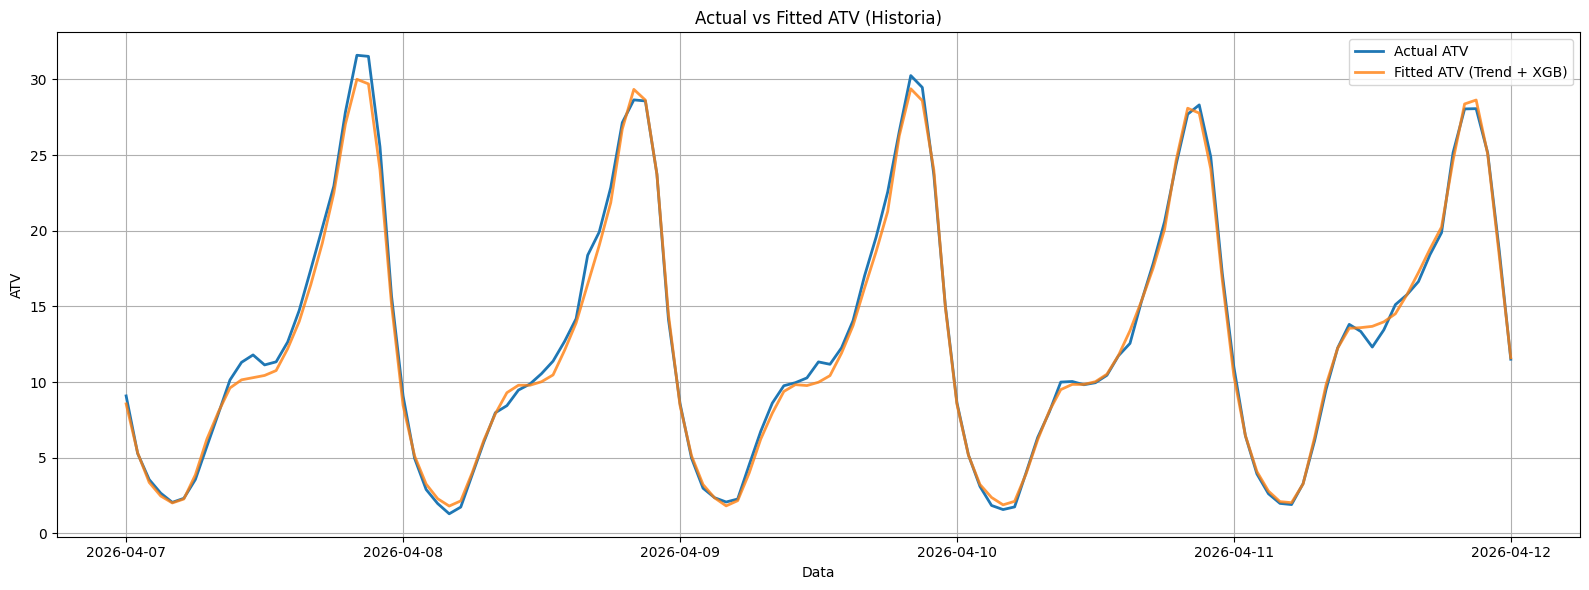

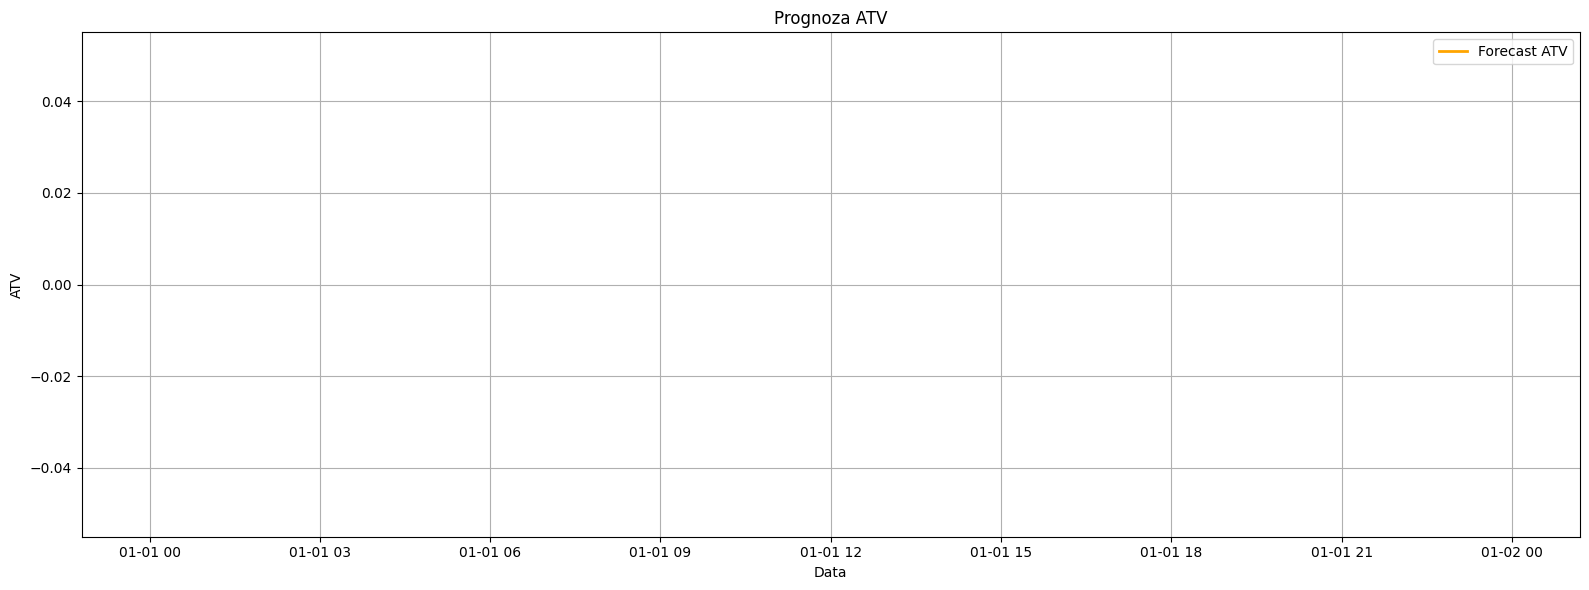

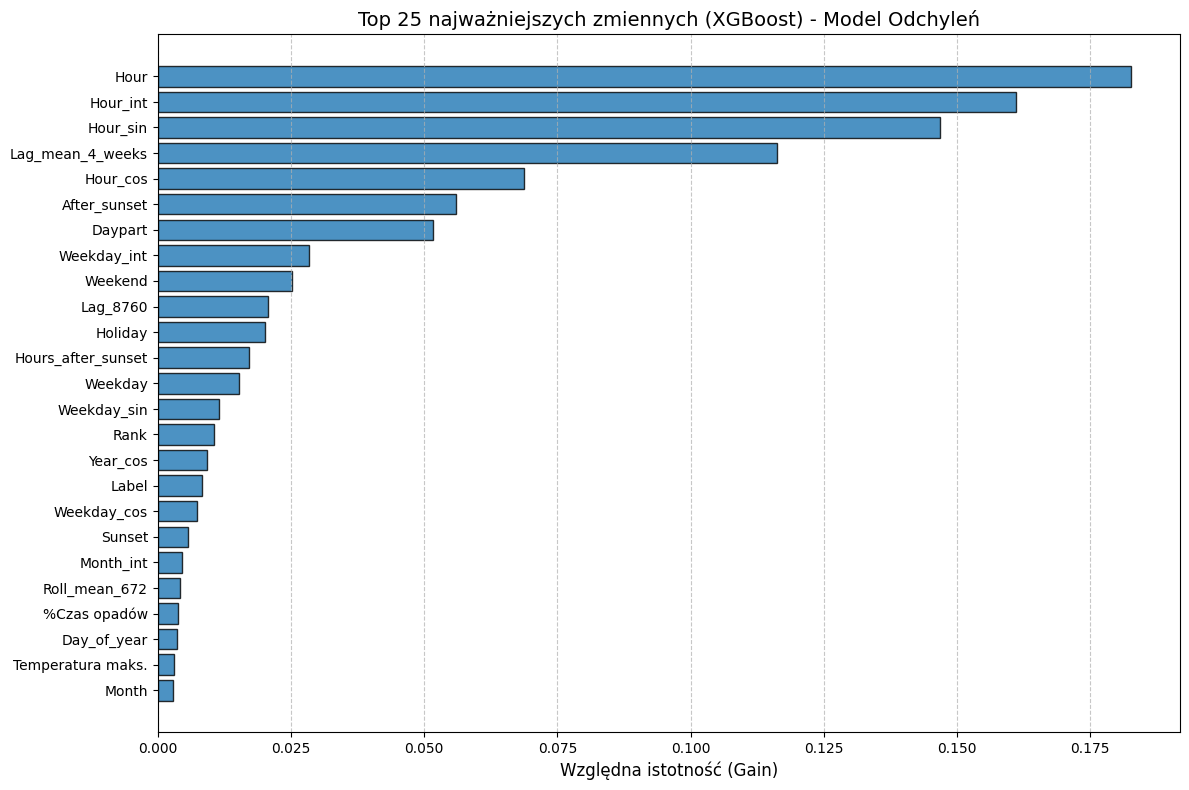

In [9]:
df_fit = df_model.copy()

# Predykcje in-sample rozbite na oba modele
pred_hist_trend = final_trend_model.predict(X[zmienne_trendu])
pred_hist_resid = final_xgb_model.predict(X)
pred_hist_combined = pred_hist_trend + pred_hist_resid

df_fit["ATV_predykcja"] = np.expm1(pred_hist_combined) if zmienna_obj == "logATV" else pred_hist_combined

df_fit["Residuals"] = df_fit["ATV"] - df_fit["ATV_predykcja"]
tabela_fit = df_fit[["DT", "Holiday", "Label", "Rank", "Temperatura maks.", "%Czas opadów", "ATV", "ATV_predykcja", "Residuals"]].copy()

# Wykres Historyczny
plot_df = tabela_fit.loc[(tabela_fit["DT"] >= "2026-04-07") & (tabela_fit["DT"] <= "2026-04-12")]
plt.figure(figsize=(16, 6))
plt.plot(plot_df["DT"], plot_df["ATV"], label="Actual ATV", linewidth=2)
plt.plot(plot_df["DT"], plot_df["ATV_predykcja"], label="Fitted ATV (Trend + XGB)", linewidth=2, alpha=0.8)
plt.title("Actual vs Fitted ATV (Historia)")
plt.xlabel("Data")
plt.ylabel("ATV")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Wykres Prognozy
plot_forecast = prognoza.loc[(prognoza["DT"] >= "2026-05-01") & (prognoza["DT"] <= "2026-05-08")]
plt.figure(figsize=(16, 6))
plt.plot(plot_forecast["DT"], plot_forecast["ATV_predykcja"], linewidth=2, color="orange", label="Forecast ATV")
plt.title("Prognoza ATV")
plt.xlabel("Data")
plt.ylabel("ATV")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Ważność Zmiennych (Tylko dla XGBoost prognozującego reszty)
feature_importances = pd.DataFrame({'Zmienna': X.columns, 'Istotność': final_xgb_model.feature_importances_}).sort_values(by='Istotność', ascending=True)
plot_data = feature_importances.tail(25)

plt.figure(figsize=(12, 8))
plt.barh(plot_data['Zmienna'], plot_data['Istotność'], color='#1f77b4', edgecolor='black', alpha=0.8)
plt.title("Top 25 najważniejszych zmiennych (XGBoost) - Model Odchyleń", fontsize=14)
plt.xlabel("Względna istotność (Gain)", fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()